<a href="https://colab.research.google.com/github/NikitaMarnykh/labor_market_analysis/blob/main/%D0%9C%D0%B0%D1%80%D0%BD%D1%8B%D1%85_%D0%9D_%D0%92_%D0%B8_%D0%9E%D0%B1%D0%BE%D1%80%D0%BE%D1%82%D0%BE%D0%B2_%D0%9C_%D0%92_%D1%80%D1%8B%D0%BD%D0%BE%D0%BA_%D1%82%D1%80%D1%83%D0%B4%D0%B0_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B2%D0%B7%D0%B0%D0%B8%D0%BC%D0%BE%D1%81%D0%B2%D1%8F%D0%B7%D0%B8_%D0%B4%D0%B2%D1%83%D1%85_%D0%BA%D0%BE%D0%BB%D0%B8%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Признаки, которые будут использованы для дальнейшего анализа**

Количественные признаки:

  - минимальная заработная плат (salary_from)
  
  - максимальная заработная плата (salary_to)

## 9. Установка и подключение зависимостей для анализа взаимосвязей количетсвенных признаков

Устанавливаем все необходимые зависимости

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install seaborn

Подключаем все необходимые зависимости

In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as stats

import seaborn as sns

Подгружаем репозиторий для работы с ним

In [ ]:
!git clone https://github.com/NikitaMarnykh/labor_market_analysis

Cloning into 'labor_market_analysis'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 103 (delta 60), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 69.53 MiB | 7.08 MiB/s, done.
Resolving deltas: 100% (60/60), done.


Перейдём в установленный репозиторий

In [ ]:
%cd labor_market_analysis/

/content/labor_market_analysis


Сохраним датасет в переменную

In [ ]:
dataset = pd.read_csv('cleaned_hh_hard.csv',
                      na_values=['NA', 'N/A', 'null', 'missing', '-', '?', '...'],
                      dtype={
                             'id': 'Int64', 'professional_roles': 'string',
                             'experience': 'category', 'schedule': 'category',
                             'employment': 'category', 'employer': 'string',
                             'accept_handicapped': 'category', 'key_skills': 'string',
                             'city': 'string', 'salary_from': 'Int64',
                             'salary_to': 'Int64', 'field_of_activity': 'category',

                      },
                      keep_default_na=True,
                      na_filter=True)

Посмотрим информацию о датасете

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81412 entries, 0 to 81411
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  81412 non-null  Int64   
 1   professional_roles  81412 non-null  string  
 2   experience          81412 non-null  category
 3   schedule            81412 non-null  category
 4   employment          81412 non-null  category
 5   employer            81412 non-null  string  
 6   accept_handicapped  81412 non-null  category
 7   key_skills          81412 non-null  string  
 8   city                81412 non-null  string  
 9   salary_from         81412 non-null  Int64   
 10  salary_to           81412 non-null  Int64   
 11  field_of_activity   81412 non-null  category
dtypes: Int64(3), category(5), string(4)
memory usage: 5.0 MB


## 10. Анализ взаимосвязи двух количественных признаков

### 10.1 Проверка распределения количественных признаков на нормальность

Сохраним количественные признаки в переменную numerical_traits

In [ ]:
numerical_traits = dataset[['salary_from', 'salary_to']]

Посмотрим коэффициент асимметрии для всех количественных признаков

In [ ]:
numerical_traits.skew()

,0
salary_from,2.235021
salary_to,2.441918


Посмотрим коэффициент эксцесса для всех количественных признаков

In [ ]:
numerical_traits.kurtosis()

,0
salary_from,9.092746
salary_to,13.015918


Проверим распределения признаков на нормальность. Так как размер датасета очень большой — 81412 наблюдений, — используем критерий Андерсона-Дарлинга.

Гипотеза Н0: наблюдаемая выборка принадлежит нормальной генеральной совокупности, уровень значимости полагаем равным 0,05

In [ ]:
cols = numerical_traits.columns.tolist()
norm_results = pd.DataFrame(columns=['Статистика', 'Критическое значение (5%)', 'Нормальность'], index=cols)

for col in cols:
    result = stats.anderson(numerical_traits[col], dist='norm')
    print(result[-1])
    norm_results.at[col, 'Статистика'] = result.statistic
    norm_results.at[col, 'Критическое значение (5%)'] = result.critical_values[2]  # для α=0.05
    norm_results.at[col, 'Нормальность'] = 'Нормальное' if result.statistic < result.critical_values[2] else 'Не нормальное'

norm_results

[15.  10.   5.   2.5  1. ]
[15.  10.   5.   2.5  1. ]


,Статистика,Критическое значение (5%),Нормальность
salary_from,3481.319392,0.787,Не нормальное
salary_to,3188.991927,0.787,Не нормальное


Выводы по анализу на нормальность:
  * Коэффициенты асимметрии (skewness):

    - Все признаки имеют положительную асимметрию (skewness > 0).
    
    - У признака salary_from асимметрия наименее выражена (2.267841). Наибольшая асимметрия наблюдается у признака salary_to (2.458314), что указывает на правостороннее смещение распределения.

  * Коэффициенты эксцесса (kurtosis):

    - Все признаки имеют положительный эксцесс (лептокуртическое распределение — более островершинное, чем нормальное).

  * Тест Андерсона-Дарлинга (уровень значимости = 0.05):

    - Для всех признаков критическое значение > 0.05, что приводит к отвержению нулевой гипотезы (H₀) о нормальности распределения.

**Таким образом, ни один из анализируемых признаков не следует считать нормально распределенным.**


### 10.2 Признаки salary_from и salary_to

**Сформулируем гипотезу H₀: Корреляция равна нулю (нет линейной связи). Уровень значимости полагаем 0.05**

Построим диаграмму рассеяния

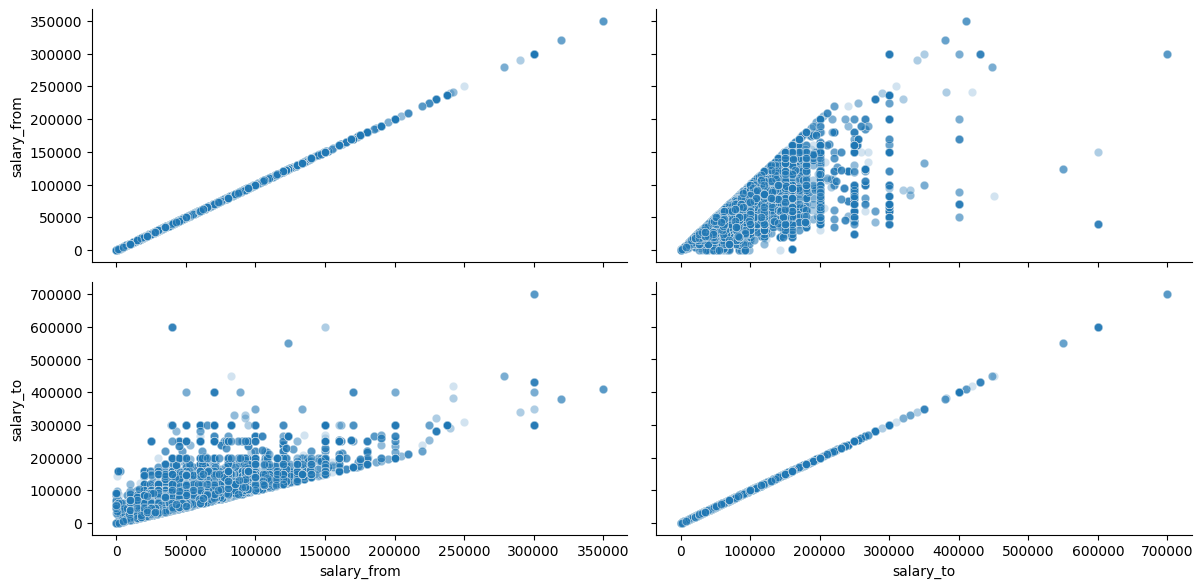

In [ ]:
columns = ['salary_from', 'salary_to']
plot = sns.PairGrid(numerical_traits[columns],
                   height=3,
                   aspect=2)
plot.map(sns.scatterplot, alpha=0.2)
plt.show()

Посмотрим коэффициент корреляции признаков

In [ ]:
numerical_traits[columns].corr(method='pearson')

,salary_from,salary_to
salary_from,1.000000,0.785934
salary_to,0.785934,1.000000


Построим теполовую карту для признаков

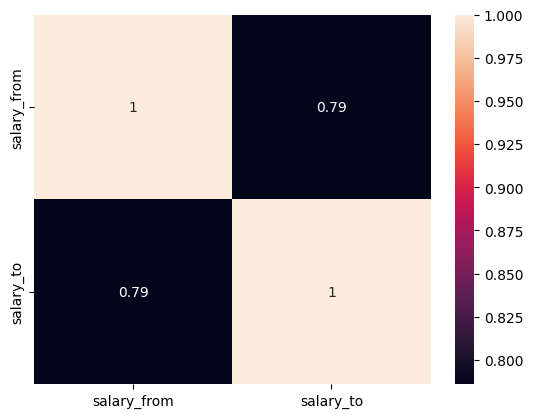

In [ ]:
heat_map = sns.heatmap(numerical_traits[columns].corr(method='pearson'), annot=True)
plt.show()

Проверим нулевую гипотезу, используя критерий Пирсона, поскольку исследуемые признаки являются количественными, а также наблюдается линейная зависимость между ними

In [ ]:
stats.pearsonr(numerical_traits[columns[0]], numerical_traits[columns[1]])

PearsonRResult(statistic=np.float64(0.7859340826797143), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков (присутствует или отсутствует на диаграммах, какая взаимосвязь (линейная, нелинейная), значима или нет):

  - По диаграммам можно сказать о наличии связи.

  - Коэффициент кореляции Пирсона указывает на сильную связь

  - Гипотеза H₀ (об отсутствии корреляции) отвергается. Связь статистически значима (p < 0.05).

  - Тип связи: сильная линейная